# 5b — Model Training & Evaluation

## What This Notebook Does
This notebook trains and evaluates three machine learning models
to predict whether a traffic accident will be **high-risk** (Severity ≥ 3).

It loads preprocessed data from `5a_data_prep_for_ml.ipynb`.

### Models
| # | Model | Type | Lecture Reference |
|---|-------|------|-------------------|
| 1 | Logistic Regression | Linear baseline | Week 9 — gradient descent, linear decision boundary |
| 2 | Random Forest | Ensemble — Bagging | Week 10 — bagging + random feature subsets |
| 3 | Gradient Boosting | Ensemble — Boosting | Week 10 — sequential weak learners |

### Evaluation Metrics
- **Accuracy** — correct predictions / total predictions
- **Precision** — TP / (TP + FP)
- **Recall** — TP / (TP + FN)
- **F1-score** — harmonic mean of Precision and Recall
- **ROC-AUC** — area under the ROC curve

In [1]:
# Install required packages
!pip install kaggle statsmodels scikit-learn -q
print("Libraries installed!")

Libraries installed!


## Import Libraries

In [2]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
os.makedirs("figures/ml", exist_ok=True)

print("All imports successful!")

All imports successful!


## Load Preprocessed Data

Load all arrays saved by `5a_data_prep_for_ml.ipynb`.
No preprocessing needed here — data is ready to use.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/DSA210_ml_data"

X_train        = pd.read_csv(f"{save_dir}/X_train.csv")
X_test         = pd.read_csv(f"{save_dir}/X_test.csv")
X_train_scaled = pd.read_csv(f"{save_dir}/X_train_scaled.csv")
X_test_scaled  = pd.read_csv(f"{save_dir}/X_test_scaled.csv")
y_train        = pd.read_csv(f"{save_dir}/y_train.csv").squeeze()
y_test         = pd.read_csv(f"{save_dir}/y_test.csv").squeeze()
joblib.dump

with open(f"{save_dir}/numeric_features.json", "r") as f:
    numeric_features = json.load(f)
with open(f"{save_dir}/baseline.json", "r") as f:
    baseline_results = json.load(f)

print("Loaded from Google Drive!")

Mounted at /content/drive
Loaded from Google Drive!


## Evaluation Helper Function

Reusable function that:
1. Trains the model on training data
2. Prints all metrics — Accuracy, Precision, Recall, F1, ROC-AUC
3. Plots and saves Confusion Matrix + ROC Curve
4. Returns a results dictionary for the final comparison table



In [4]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name="Model"):

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None


    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None


    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    if auc:
        print(f"  ROC-AUC   : {auc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=["Low Risk", "High Risk"]))

    # Confusion Matrix + ROC Curve side by side
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(model_name, fontsize=13, fontweight="bold")

    # Confusion Matrix — shows TP, TN, FP, FN counts
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion Matrix")

    # ROC Curve — True Positive Rate vs False Positive Rate
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        axes[1].plot(fpr, tpr, lw=2.5, color="#1565C0", label=f"AUC = {auc:.3f}")
        axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title("ROC Curve")
        axes[1].legend()

    plt.tight_layout()
    fname = model_name.lower().replace(" ", "_")
    plt.savefig(f"figures/ml/{fname}_evaluation.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: figures/ml/{fname}_evaluation.png")

    return {
        "model": model_name, "accuracy": acc,
        "precision": prec, "recall": rec,
        "f1": f1, "auc": auc
    }

print("evaluate_model() is ready!")

evaluate_model() is ready!


## Model 1: Logistic Regression (Baseline)

- Fits a linear decision boundary in feature space
- Parameters (weights `w`) optimized using gradient descent to minimize loss
- Each coefficient shows direction and magnitude of a feature's effect on risk
- `class_weight='balanced'` corrects the 79% / 21% class imbalance automatically




  Logistic Regression
  Accuracy  : 0.5983
  Precision : 0.3044
  Recall    : 0.6901
  F1-score  : 0.4224
  ROC-AUC   : 0.6805

              precision    recall  f1-score   support

    Low Risk       0.87      0.57      0.69     69318
   High Risk       0.30      0.69      0.42     18746

    accuracy                           0.60     88064
   macro avg       0.59      0.63      0.56     88064
weighted avg       0.75      0.60      0.63     88064



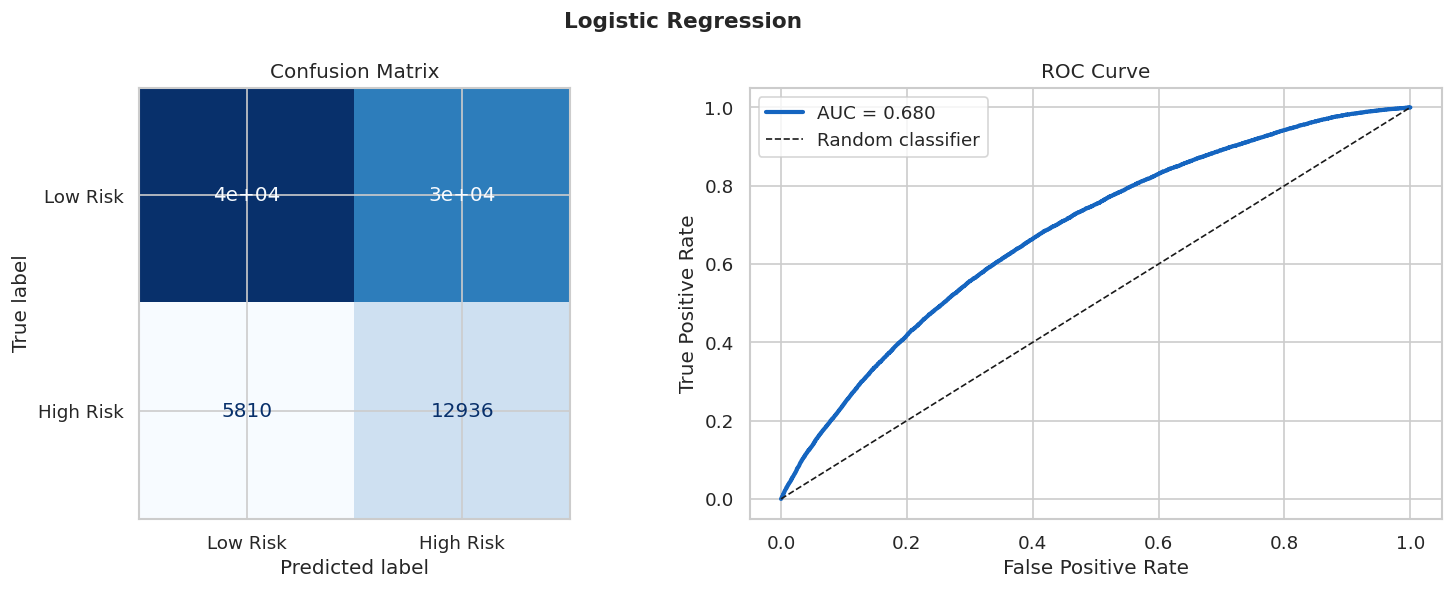

Saved: figures/ml/logistic_regression_evaluation.png


In [5]:
# Logistic Regression — linear classifier
# solver='lbfgs'          → gradient-based optimization
# max_iter=1000           → ensure convergence
# class_weight='balanced' → corrects 79%/21% class imbalance
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="lbfgs",
    n_jobs=-1
)


results_lr = evaluate_model(
    lr,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    model_name="Logistic Regression"
)

## Logistic Regression: Coefficient Plot

Since features are standardized, coefficients are directly comparable in magnitude.
- **Red bar (positive)** → feature increases predicted high-risk probability
- **Blue bar (negative)** → feature decreases predicted high-risk probability
- Larger absolute value = stronger effect on the prediction

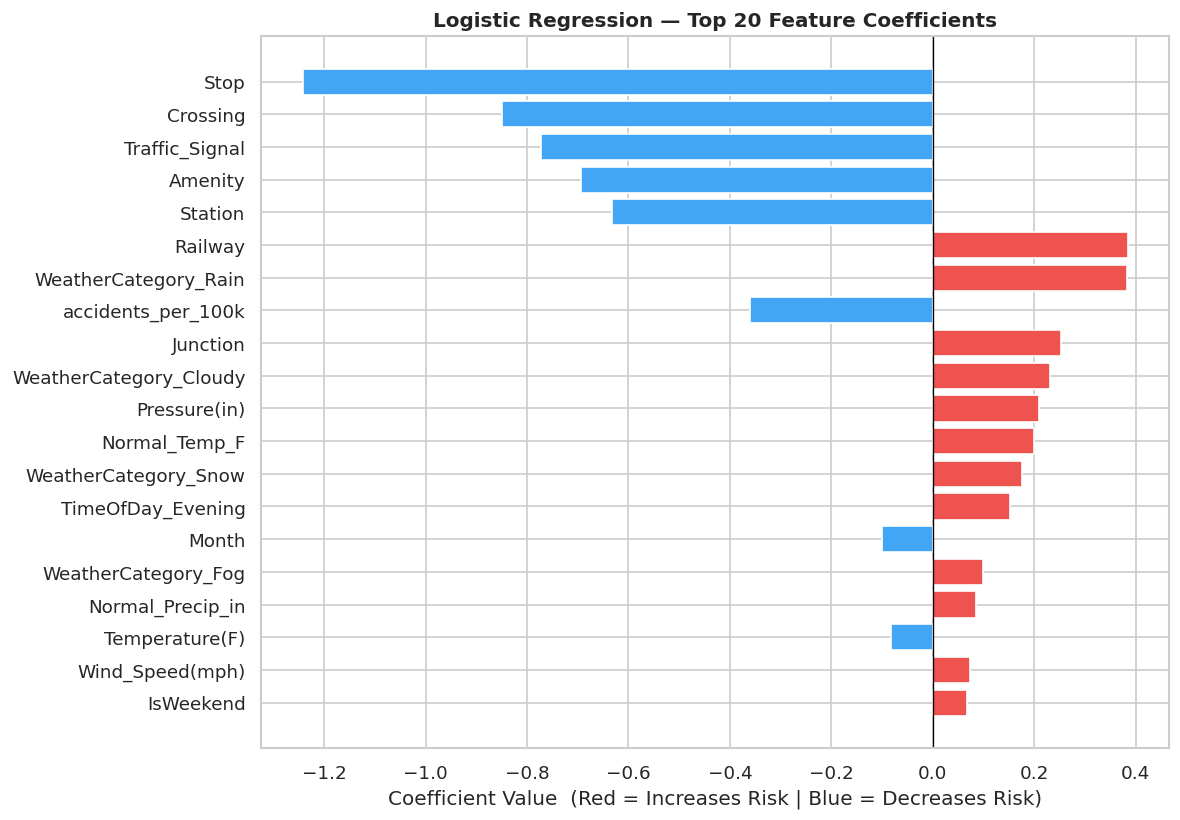

Saved: figures/ml/logreg_coefficients.png


In [6]:
coef_df = pd.DataFrame({
    "Feature":     X_train_scaled.columns,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).head(20)

# Red = increases risk, Blue = decreases risk
colors = ["#EF5350" if c > 0 else "#42A5F5" for c in coef_df["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient Value  (Red = Increases Risk | Blue = Decreases Risk)")
ax.set_title("Logistic Regression — Top 20 Feature Coefficients",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("figures/ml/logreg_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: figures/ml/logreg_coefficients.png")

## Model 2: Random Forest Classifier

Ensemble Learning — Bagging + Random Forests


Two sources of randomness
1. **Bagging** — each tree trained on a different bootstrap sample
2. **Random feature subsets** — at each split, only a random subset of features considered

Tree-based models are scale-invariant — **no StandardScaler needed.**


  Random Forest
  Accuracy  : 0.6519
  Precision : 0.3463
  Recall    : 0.7162
  F1-score  : 0.4669
  ROC-AUC   : 0.7375

              precision    recall  f1-score   support

    Low Risk       0.89      0.63      0.74     69318
   High Risk       0.35      0.72      0.47     18746

    accuracy                           0.65     88064
   macro avg       0.62      0.68      0.60     88064
weighted avg       0.78      0.65      0.68     88064



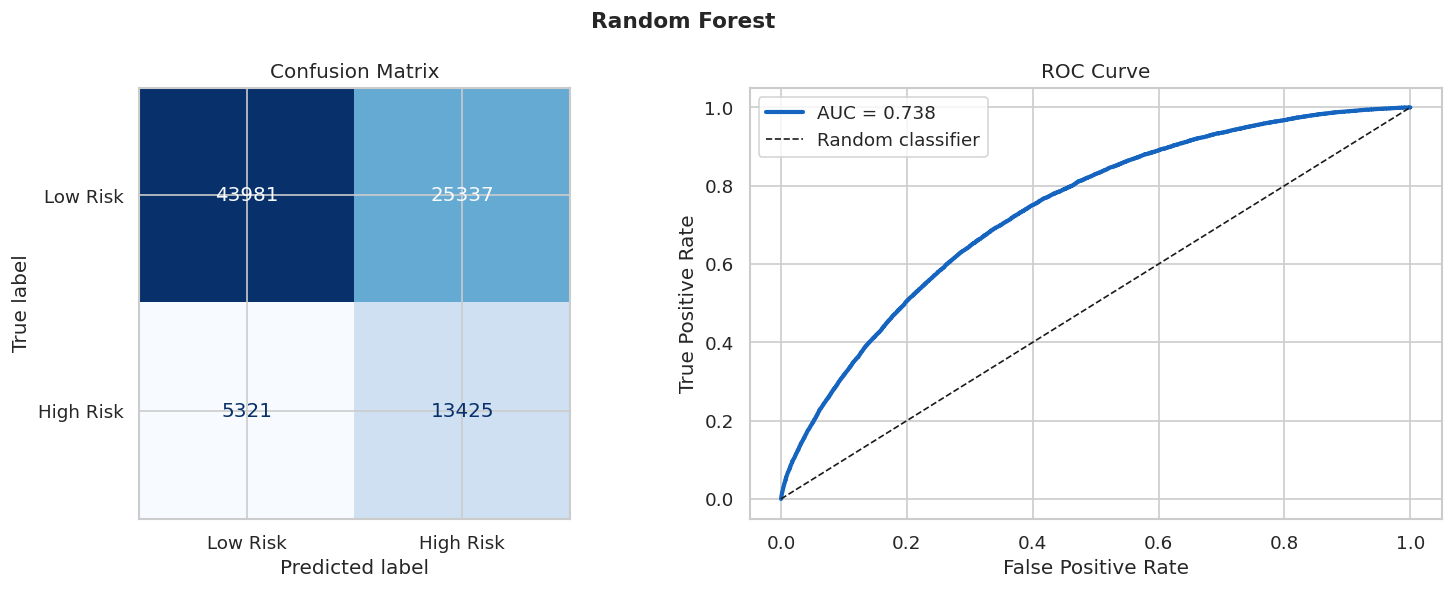

Saved: figures/ml/random_forest_evaluation.png


In [7]:
# Random Forest — bagging ensemble of decision trees (Week 10 lecture)
# n_estimators=200     → 200 trees
# max_depth=15         → limits depth to prevent overfitting
# min_samples_leaf=20  → each leaf needs at least 20 samples — regularization
# class_weight='balanced' → handles 79%/21% class imbalance
# n_jobs=-1            → parallel tree building on all CPU cores
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Tree-based model
results_rf = evaluate_model(
    rf,
    X_train, X_test,
    y_train, y_test,
    model_name="Random Forest"
)

## Random Forest: Gini Feature Importance

Feature Importance
Scikit-Learn measures a feature's importance by looking at how much
the tree nodes that use that feature reduce impurity on average
across all trees in the forest.

This is the Mean Decrease in Gini Impurity — built into Random Forest.

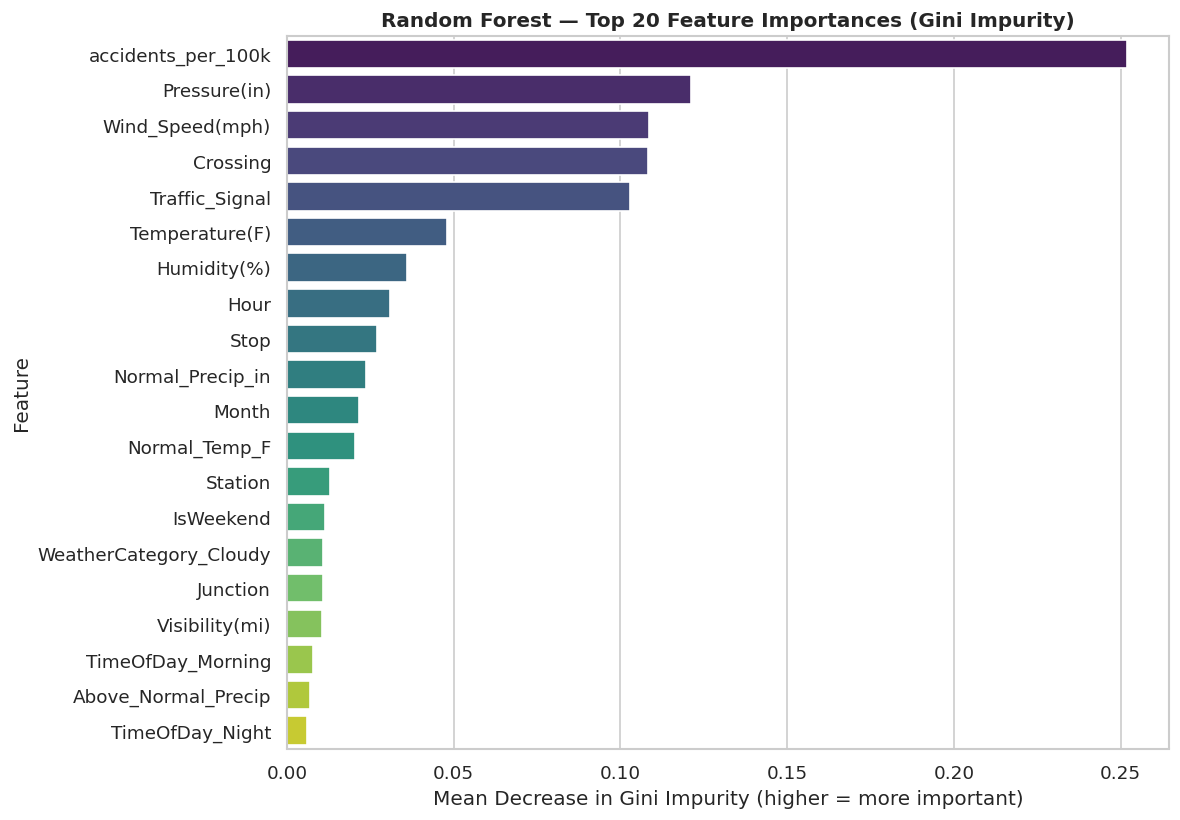

Saved: figures/ml/rf_feature_importance.png


In [8]:
# Extract Gini importance scores from the fitted Random Forest
feat_imp = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=feat_imp, x="Importance", y="Feature", ax=ax, palette="viridis")
ax.set_title("Random Forest — Top 20 Feature Importances (Gini Impurity)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Mean Decrease in Gini Impurity (higher = more important)")
plt.tight_layout()
plt.savefig("figures/ml/rf_feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: figures/ml/rf_feature_importance.png")

## Model 3: Gradient Boosting Classifier

Gradient Boosted Decision Trees

Algorithm overview:
1. Build a base tree (just the root node)
2. Build next tree based on the residual errors of the previous tree
3. Combine all trees — repeat step 2

Key difference from Random Forest: trees are sequential, not parallel.
`HistGradientBoostingClassifier` is sklearn's fast histogram-based variant
— ideal for large datasets. Does not need feature scaling.






  Gradient Boosting
  Accuracy  : 0.6794
  Precision : 0.3698
  Recall    : 0.7190
  F1-score  : 0.4884
  ROC-AUC   : 0.7602

              precision    recall  f1-score   support

    Low Risk       0.90      0.67      0.77     69318
   High Risk       0.37      0.72      0.49     18746

    accuracy                           0.68     88064
   macro avg       0.63      0.69      0.63     88064
weighted avg       0.79      0.68      0.71     88064



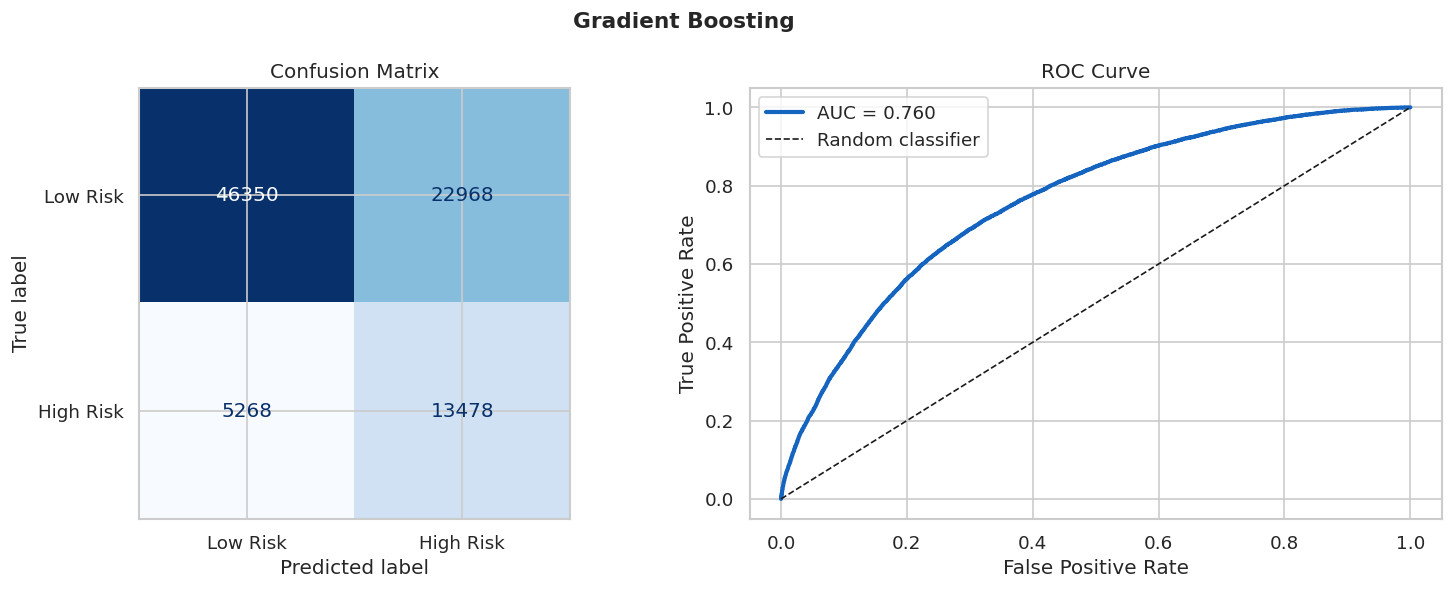

Saved: figures/ml/gradient_boosting_evaluation.png


In [9]:
gb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)


results_gb = evaluate_model(
    gb,
    X_train, X_test,
    y_train, y_test,
    model_name="Gradient Boosting"
)

##  ROC Curves: All Models Together

The ROC curve plots True Positive Rate vs False Positive Rate at every threshold.
  AUC (Area Under the Curve)** summarizes discrimination ability:
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random classifier (the diagonal line)

All three models plotted together for direct comparison.

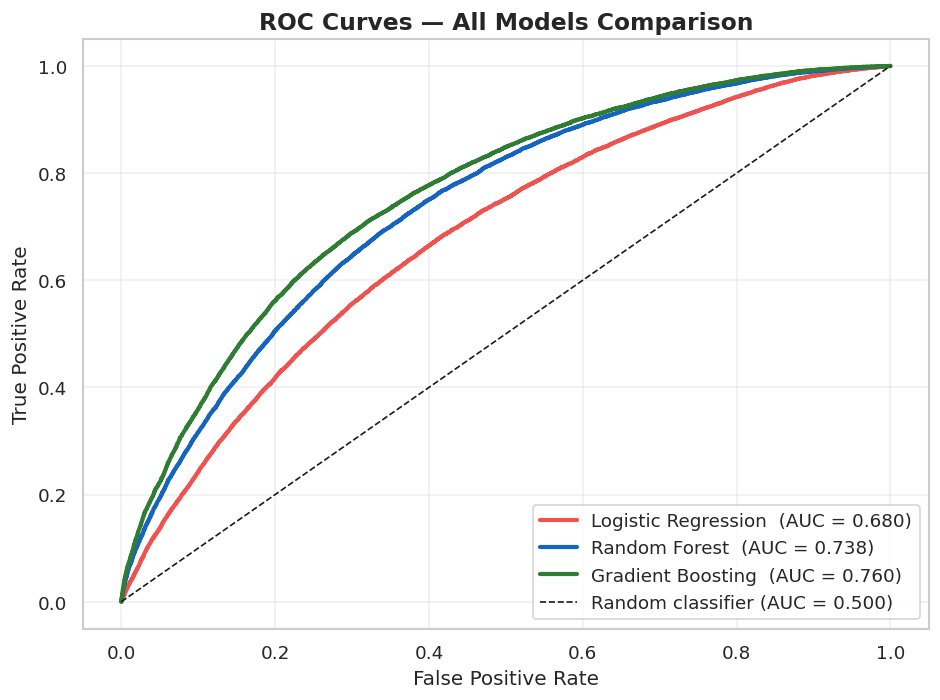

Saved: figures/ml/roc_all_models.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

# Each model with its own color
model_configs = [
    (lr, X_test_scaled, "Logistic Regression", "#EF5350"),
    (rf, X_test,        "Random Forest",        "#1565C0"),
    (gb, X_test,        "Gradient Boosting",    "#2E7D32"),
]

for model, X_te, name, color in model_configs:
    prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{name}  (AUC = {auc:.3f})")

# Diagonal = random classifier baseline
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/ml/roc_all_models.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: figures/ml/roc_all_models.png")

## Model Comparison: Summary Table & Chart

All three models compared against each other and the majority class baseline
computed in `5a_data_prep_for_ml.ipynb`.


── MODEL COMPARISON ──────────────────────────────────────────
                     accuracy  precision  recall      f1     auc
model                                                           
Logistic Regression    0.5983     0.3044  0.6901  0.4224  0.6805
Random Forest          0.6519     0.3463  0.7162  0.4669  0.7375
Gradient Boosting      0.6794     0.3698  0.7190  0.4884  0.7602
Majority Baseline      0.7871     0.0000  0.0000  0.0000  0.5000

Best model by F1    : Gradient Boosting
Best model by AUC   : Gradient Boosting


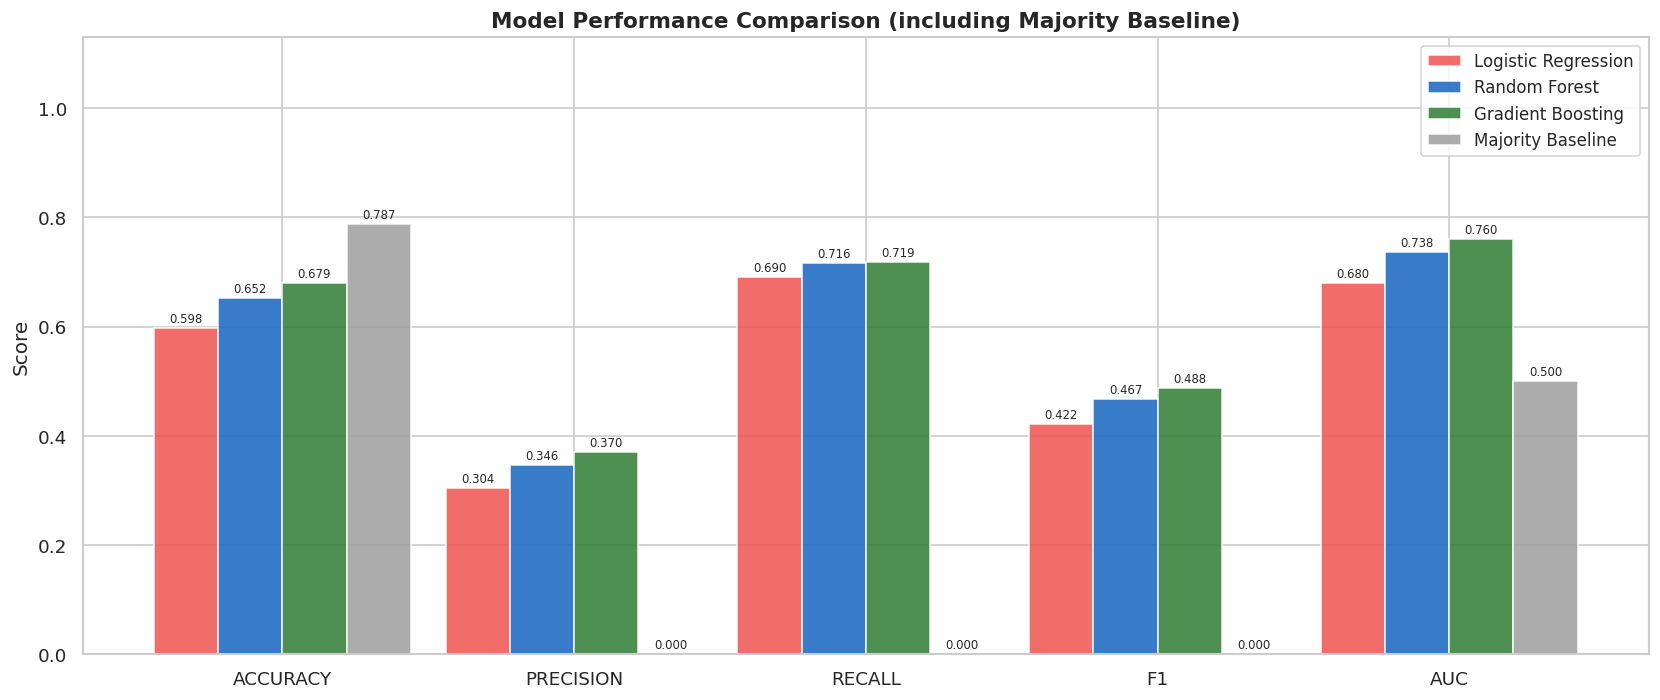

Saved: figures/ml/model_comparison.png


In [11]:
results_df = pd.DataFrame([results_lr, results_rf, results_gb])
results_df.set_index("model", inplace=True)
results_display = results_df[["accuracy", "precision", "recall", "f1", "auc"]].round(4)


results_display.loc["Majority Baseline"] = [
    baseline_results["accuracy"], 0.0, 0.0, baseline_results["f1"], 0.5
]

print("\n── MODEL COMPARISON ──────────────────────────────────────────")
print(results_display.to_string())
print(f"\nBest model by F1    : {results_display.drop('Majority Baseline')['f1'].idxmax()}")
print(f"Best model by AUC   : {results_display.drop('Majority Baseline')['auc'].idxmax()}")


metrics      = ["accuracy", "precision", "recall", "f1", "auc"]
x            = np.arange(len(metrics))
width        = 0.22
plot_models  = ["Logistic Regression", "Random Forest", "Gradient Boosting", "Majority Baseline"]
model_colors = ["#EF5350", "#1565C0", "#2E7D32", "#9E9E9E"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (mname, color) in enumerate(zip(plot_models, model_colors)):
    vals = [results_display.loc[mname, m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=mname, color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.upper() for m in metrics], fontsize=11)
ax.set_ylim(0, 1.13)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison (including Majority Baseline)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/ml/model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: figures/ml/model_comparison.png")

## Save Trained Models

Save all three trained models to disk so that
`5c_model_analysis.ipynb` can load them directly
without retraining.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/DSA210_ml_data"

# Save trained models to Drive
joblib.dump(lr, f"{SAVE_DIR}/model_lr.pkl")
joblib.dump(rf, f"{SAVE_DIR}/model_rf.pkl")
joblib.dump(gb, f"{SAVE_DIR}/model_gb.pkl")

# Save results table
results_display.to_csv(f"{SAVE_DIR}/results_table.csv")

print("Models saved to Google Drive!")
print()
for fname in sorted(os.listdir(SAVE_DIR)):
    print(f"    {fname}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models saved to Google Drive!

    X_test.csv
    X_test_scaled.csv
    X_train.csv
    X_train_scaled.csv
    baseline.json
    model_gb.pkl
    model_lr.pkl
    model_rf.pkl
    numeric_features.json
    results_table.csv
    scaler.pkl
    y_test.csv
    y_train.csv


## Notebook B Complete

All three models trained and saved.

**Next step → open `5c_model_analysis.ipynb`**

### Figures Saved

| File | Contents |
|------|----------|
| `figures/ml/logistic_regression_evaluation.png` | Confusion Matrix + ROC Curve |
| `figures/ml/logreg_coefficients.png` | Top 20 feature coefficients |
| `figures/ml/random_forest_evaluation.png` | Confusion Matrix + ROC Curve |
| `figures/ml/rf_feature_importance.png` | Top 20 Gini importances |
| `figures/ml/gradient_boosting_evaluation.png` | Confusion Matrix + ROC Curve |
| `figures/ml/roc_all_models.png` | All 3 ROC curves together |
| `figures/ml/model_comparison.png` | Grouped bar chart comparison |

### Key Results
*(fill in after running)*

| Model | F1 | ROC-AUC |
|-------|----|---------|
| Majority Baseline | 0.00 | 0.50 |
| Logistic Regression | — | — |
| Random Forest | — | — |
| Gradient Boosting | — | — |

In [17]:
import shutil
from google.colab import files


shutil.make_archive("ml_figures_5b", "zip", "figures/ml")
files.download("ml_figures_5b.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>